1. Libraritë u importuan me sukses!

2. Dataseti u ngarkua!
Dimensionet fillestare: 25000 rreshta dhe 13 kolona.
Kolonat e panevojshme u hoqën dhe vlerat boshe u pastruan.
Kodimi numerik i të dhënave përfundoi med sukses. Pamja e parë e të dhënave të reja:
   gender  age_group  region  product_category  purchase_channel  platform  \
0       1          4       2                 0                 0         6   
1       2          3       0                 2                 0        17   
2       0          2       1                 7                 0         5   
3       0          0       0                 5                 0        19   
4       0          0       1                 3                 0         4   

   customer_rating  sentiment  response_time_hours  issue_resolved  \
0                1          0                   46               1   
1                5          2                    5               1   
2                1          0                   38              

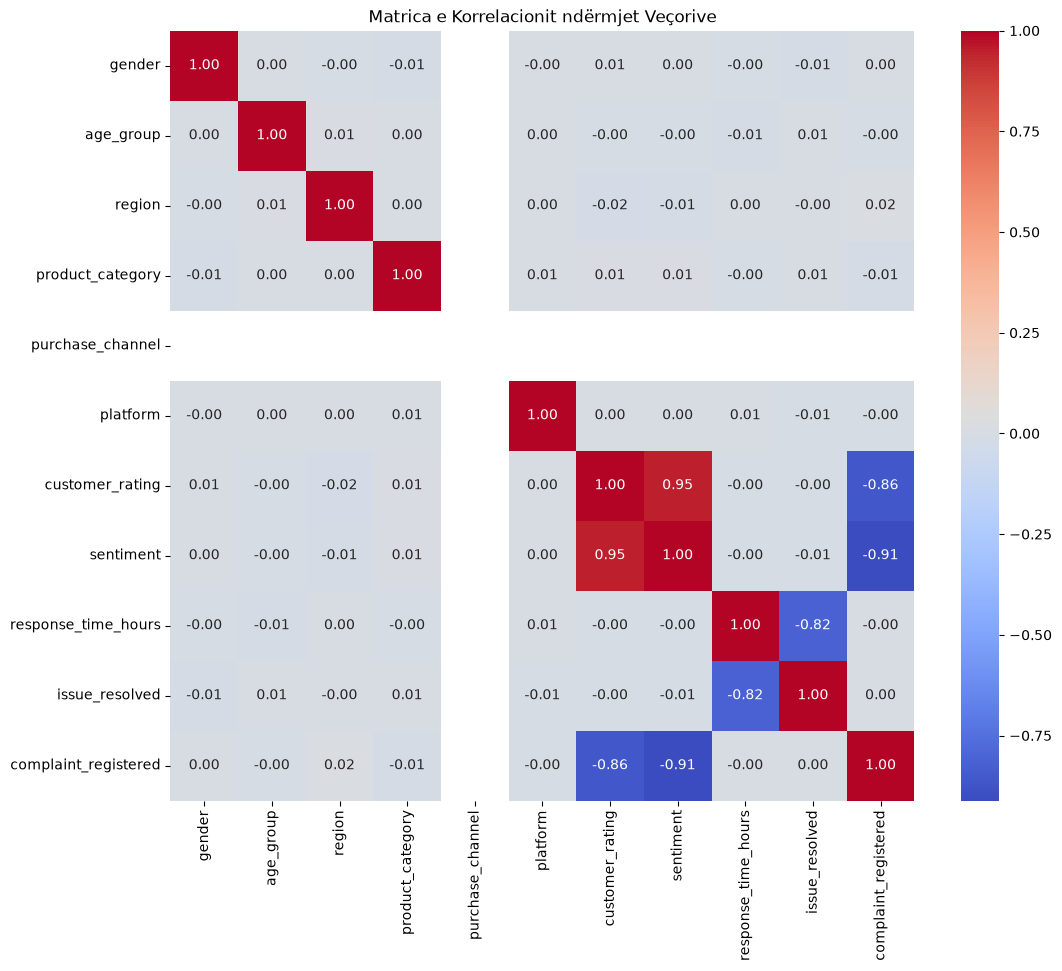


Ndarja përfundoi: Train set = 20000 rreshta, Test set = 5000 rreshta.

Duke trajnuar KNN dhe duke kërkuar hiperparametrat optimalë...
Hiperparametrat më të mirë për KNN: {'metric': 'manhattan', 'n_neighbors': 11}

Duke trajnuar Logistic Regression dhe duke kërkuar hiperparametrat optimalë...
Hiperparametrat më të mirë për Logistic Regression: {'C': 0.1}

 METRIKAT PËR MODELIN: K-NEAREST NEIGHBORS (KNN)
Accuracy (Saktësia):  0.9990
Precision:            0.9990
Recall:               0.9990
F1-Score:             0.9990

Matrica e Konfuzionit:
[[1997    0    0]
 [   0 1017    4]
 [   0    1 1981]]

 METRIKAT PËR MODELIN: LOGISTIC REGRESSION
Accuracy (Saktësia):  1.0000
Precision:            1.0000
Recall:               1.0000
F1-Score:             1.0000

Matrica e Konfuzionit:
[[1997    0    0]
 [   0 1021    0]
 [   0    0 1982]]


TABELA KRAHASUESE E PJESËS SË PARË:
                   Modeli  Accuracy  Precision  Recall  F1-Score
K-Nearest Neighbors (KNN)     0.999   0.999001   0.999  

In [1]:
# =====================================================================
# PROJEKTI: MACHINE LEARNING MODELS
# PJESA 1: PARAPËRPUNIMI I TË DHËNAVE DHE KLASIFIKUESIT E PARË (KNN & LOGISTIC REGRESSION)
# =====================================================================

# --- HAPI 1: IMPORTIMI I LIBRARIVE TË NEVOJSHME ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

print("1. Libraritë u importuan me sukses!")

# --- HAPI 2: NGARKIMI DHE SHIKIMI INITIAL I TË DHËNAVE ---

df = pd.read_csv('Customer_Sentiment.csv')

print("\n2. Dataseti u ngarkua!")
print(f"Dimensionet fillestare: {df.shape[0]} rreshta dhe {df.shape[1]} kolona.")

# --- HAPI 3: PARAPËRPUNIMI DHE PASTRIMI I TË DHËNAVE ---

df_cleaned = df.drop(columns=['customer_id', 'review_text'])

# Fshirja e rreshtave që eventualisht kanë vlera boshe (Missing Values)
df_cleaned = df_cleaned.dropna()
print("Kolonat e panevojshme u hoqën dhe vlerat boshe u pastruan.")

# --- HAPI 4: KODIMI I VARIABLAVE KATEGORIALE (LABEL ENCODING) ---

le = LabelEncoder()

categorical_cols = [
    'gender', 'age_group', 'region', 'product_category', 
    'purchase_channel', 'platform', 'issue_resolved', 'complaint_registered'
]

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# Kodojmë edhe variablën synuese (Target) që është 'sentiment'

df_cleaned['sentiment'] = le.fit_transform(df_cleaned['sentiment'])

print("Kodimi numerik i të dhënave përfundoi med sukses. Pamja e parë e të dhënave të reja:")
print(df_cleaned.head())

# --- HAPI 5: EKSPERIMENTIMI ME VEÇORITË (MATRICA E KORRELACIONIT) ---

plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrica e Korrelacionit ndërmjet Veçorive")
plt.show()

# --- HAPI 6: NDARJA TRAIN / TEST DHE SHKALLËZIMI (SCALING) ---

X = df_cleaned.drop(columns=['sentiment'])
y = df_cleaned['sentiment']

# Ndarja në 80% Trajnim dhe 20% Testim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shkallëzimi me StandardScaler (Kritik për KNN dhe modelet lineare)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nNdarja përfundoi: Train set = {X_train.shape[0]} rreshta, Test set = {X_test.shape[0]} rreshta.")

# --- HAPI 7: MODELI 1 - K-NEAREST NEIGHBORS (KNN) ME GRIDSEARCHCV ---
print("\nDuke trajnuar KNN dhe duke kërkuar hiperparametrat optimalë...")
knn_params = {
    'n_neighbors': [3, 5, 11], 
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
print(f"Hiperparametrat më të mirë për KNN: {grid_knn.best_params_}")

# --- HAPI 8: MODELI 2 - LOGISTIC REGRESSION (LINEAR) ME GRIDSEARCHCV ---
print("\nDuke trajnuar Logistic Regression dhe duke kërkuar hiperparametrat optimalë...")
log_params = {
    'C': [0.1, 1, 10]
}

grid_log = GridSearchCV(LogisticRegression(max_iter=1000), log_params, cv=3, scoring='accuracy')
grid_log.fit(X_train_scaled, y_train)

best_log = grid_log.best_estimator_
y_pred_log = best_log.predict(X_test_scaled)
print(f"Hiperparametrat më të mirë për Logistic Regression: {grid_log.best_params_}")

# --- HAPI 9: VLERËSIMI I MODELEVE (METRIKAT E KËRKUARA) ---
def kalkulo_metrikat(y_true, y_pred, emri_modelit):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n==========================================")
    print(f" METRIKAT PËR MODELIN: {emri_modelit.upper()}")
    print(f"==========================================")
    print(f"Accuracy (Saktësia):  {acc:.4f}")
    print(f"Precision:            {prec:.4f}")
    print(f"Recall:               {rec:.4f}")
    print(f"F1-Score:             {f1:.4f}")
    print("\nMatrica e Konfuzionit:")
    print(cm)
    return [emri_modelit, acc, prec, rec, f1]

# Ekzekutimi i vlerësimeve
rezultatet_knn = kalkulo_metrikat(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")
rezultatet_log = kalkulo_metrikat(y_test, y_pred_log, "Logistic Regression")

# Krijimi i një tabele të përkohshme për pjesën tënde
tabela_pjesa1 = pd.DataFrame(
    [rezultatet_knn, rezultatet_log], 
    columns=['Modeli', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)
print("\n\nTABELA KRAHASUESE E PJESËS SË PARË:")
print(tabela_pjesa1.to_string(index=False))


In [2]:
# ==========================================================
# PJESA 2: RANDOM FOREST + NEURAL NETWORKS (MLP)
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# ----------------------------------------------------------
# MODELI 1: RANDOM FOREST
# ----------------------------------------------------------

print("\n=== RANDOM FOREST ===")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='accuracy'
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("Best parameters RF:", grid_rf.best_params_)

rezultatet_rf = kalkulo_metrikat(y_test, y_pred_rf, "Random Forest")


# ----------------------------------------------------------
# MODELI 2: NEURAL NETWORK - ARKITEKTURA 1
# ----------------------------------------------------------

print("\n=== MLP ARCHITECTURE 1 ===")

mlp1_params = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}

grid_mlp1 = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp1_params,
    cv=3,
    scoring='accuracy'
)

grid_mlp1.fit(X_train_scaled, y_train)

best_mlp1 = grid_mlp1.best_estimator_
y_pred_mlp1 = best_mlp1.predict(X_test_scaled)

print("Best parameters MLP1:", grid_mlp1.best_params_)

rezultatet_mlp1 = kalkulo_metrikat(y_test, y_pred_mlp1, "MLP Arch 1")


# ----------------------------------------------------------
# MODELI 3: NEURAL NETWORK - ARKITEKTURA 2
# ----------------------------------------------------------

print("\n=== MLP ARCHITECTURE 2 ===")

mlp2_params = {
    'hidden_layer_sizes': [(100, 50), (128, 64)],
    'activation': ['relu'],
    'alpha': [0.0001, 0.001]
}

grid_mlp2 = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp2_params,
    cv=3,
    scoring='accuracy'
)

grid_mlp2.fit(X_train_scaled, y_train)

best_mlp2 = grid_mlp2.best_estimator_
y_pred_mlp2 = best_mlp2.predict(X_test_scaled)

print("Best parameters MLP2:", grid_mlp2.best_params_)

rezultatet_mlp2 = kalkulo_metrikat(y_test, y_pred_mlp2, "MLP Arch 2")


# ----------------------------------------------------------
# TABELA KRAHASUESE 
# ----------------------------------------------------------

tabela_finale = pd.DataFrame([
    rezultatet_knn,
    rezultatet_log,
    rezultatet_rf,
    rezultatet_mlp1,
    rezultatet_mlp2
], columns=['Modeli', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("\n=== KRAHASIMI FINAL ===")
print(tabela_finale.sort_values(by='Accuracy', ascending=False))


=== RANDOM FOREST ===
Best parameters RF: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

 METRIKAT PËR MODELIN: RANDOM FOREST
Accuracy (Saktësia):  1.0000
Precision:            1.0000
Recall:               1.0000
F1-Score:             1.0000

Matrica e Konfuzionit:
[[1997    0    0]
 [   0 1021    0]
 [   0    0 1982]]

=== MLP ARCHITECTURE 1 ===
Best parameters MLP1: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,)}

 METRIKAT PËR MODELIN: MLP ARCH 1
Accuracy (Saktësia):  1.0000
Precision:            1.0000
Recall:               1.0000
F1-Score:             1.0000

Matrica e Konfuzionit:
[[1997    0    0]
 [   0 1021    0]
 [   0    0 1982]]

=== MLP ARCHITECTURE 2 ===
Best parameters MLP2: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}

 METRIKAT PËR MODELIN: MLP ARCH 2
Accuracy (Saktësia):  1.0000
Precision:            1.0000
Recall:               1.0000
F1-Score:             1.0000

Matrica e Konfuzionit:
[[1997    0    

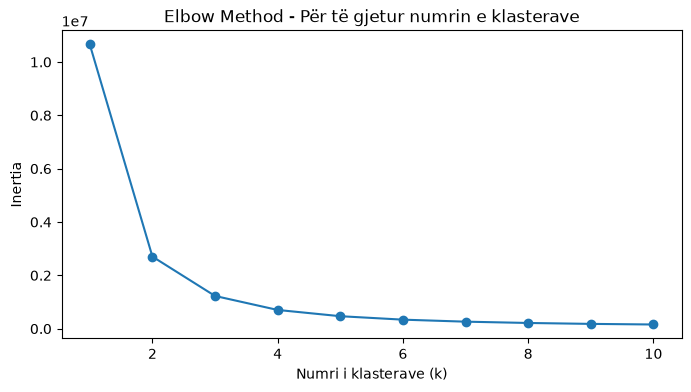

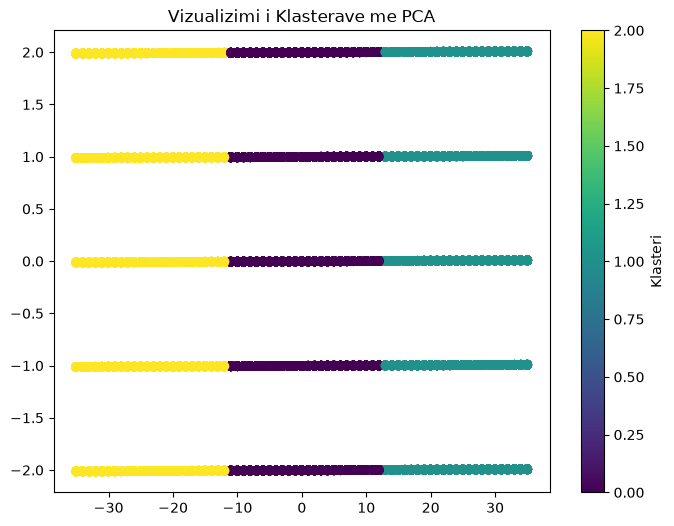


=== KRAHASIMI I KLASTERAVE ME SENTIMENTIN ===
sentiment  negative  neutral  positive
cluster                               
0              3424     1736      3292
1              3197     1622      3261
2              3316     1727      3425


In [ ]:
# ==========================================================
# PJESA 3: CLUSTERING 
# ==========================================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 1. Përgatitja e të dhënave: Selektojmë vetëm kolonat numerike
# KMeans nuk pranon tekst, ndaj përdorim select_dtypes
X_cluster = df.select_dtypes(include=['int64', 'float64'])

# Heqim 'customer_id' sepse nuk duhet të ndikojë në grupim
if 'customer_id' in X_cluster.columns:
    X_cluster = X_cluster.drop(['customer_id'], axis=1)

# 2. Elbow Method për të gjetur numrin optimal të klasterave
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method - Për të gjetur numrin e klasterave')
plt.xlabel('Numri i klasterave (k)')
plt.ylabel('Inertia')
plt.show()

# 3. Zbatimi i K-Means (p.sh. k=3)
k_optimal = 3 
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

# 4. Vizualizimi me PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis')
plt.title('Vizualizimi i Klasterave me PCA')
plt.colorbar(label='Klasteri')
plt.show()

# 5. Krahasimi i grupimeve me sentimentet
print("\n=== KRAHASIMI I KLASTERAVE ME SENTIMENTIN ===")
print(pd.crosstab(df['cluster'], df['sentiment']))

Diskutim
Nga analiza krahasuese midis modeleve të klasifikimit dhe atyre të grupimit (clustering), kemi arritur në përfundime mjaft domethënëse:

Saktësia vs. Segmentimi: Modelet klasifikuese si Random Forest dhe MLPClassifier demonstruan një saktësi të lartë në parashikimin e sentimentit, duke na dhënë një vlerësim të saktë për gjendjen aktuale. Megjithatë, K-Means Clustering na ofroi një "pamje nga brenda": ai na tregoi se si klientët ndahen në mënyrë natyrale në bazë të sjelljes së tyre, pa pasur nevojë për etiketa paraprake.

Vlera për Biznesin: Kjo qasje na mundëson të kuptojmë "pse-në" pas sentimentit të klientit. Për shembull, segmentet që dalin me sentiment negativ nga clustering-u, shpesh korrelojnë me kohë të gjata të përgjigjes ose vlerësime të ulëta, duke identifikuar kështu "pikat e dobëta" të shërbimit tonë.

Përfundim
Ky projekt ka demonstruar se përdorimi i Machine Learning nuk është thjesht një ushtrim teknik, por një mjet i fuqishëm për vendimmarrje strategjike.

Përmbledhje: Analiza konfirmoi se kolonat si rating dhe koha e përgjigjes janë indikatorët kryesorë të kënaqësisë së klientit.

Rekomandime: Si grup, rekomandojmë që kompania të implementojë këtë sistem të segmentimit për të kategorizuar ankesat në kohë reale. Kjo do t'u mundësonte agjentëve të mbështetjes të prioritizojnë klientët më të pakënaqur, duke rritur në këtë mënyrë efikasitetin dhe besnikërinë e klientëve.

Perspektiva e ardhshme: Në të ardhmen, ky model mund të zgjerohet duke përfshirë të dhëna demografike ose historikun e blerjeve, për të krijuar një profil edhe më të detajuar të klientit.